# Learning 1D mass-spring dynamics

This notebook demonstrates the NHODE framework on the 1D two-mass two-spring system.

**The system:**
```
Wall ──k₀── [m₀] ──k₁── [m₁]
```
- Spring $k_0$ connects the wall to $m_0$ (rest length $L_0$)
- Spring $k_1$ connects $m_0$ to $m_1$ (rest length $L_1$)

**The goal:**  
$m_0$ is fully observed during training, while $m_1$ is completely latent.

**Models compared:**

| Model | Abbreviation | Input | Structure |
|-------|-------------|-------|-----------|
| NHODE potential energy | NHODE $_{\text{pot}}$ | $q \in \mathbb{R}^2$ | Learns $U_\theta(q)$, derives $\dot{y}$ via Hamilton's eqs. Known masses. |
| NHODE total energy | NHODE $_\text{tot}$ | $x \in \mathbb{R}^4$ | Learns $\mathcal{H}_\theta(y)$, derives $\dot{y}$ via Hamilton's eqs. Mass-agnostic. |
| Physically-structured NODE | NODE $_\text{phys}$ | $x \in \mathbb{R}^4$ | Known masses for $\dot{q}$; MLP predicts $\dot{p}$. |
| Vanilla NODE | NODE $_\text{vanilla}$ | $x \in \mathbb{R}^4$ | MLP predicts full $\dot{y}$. |

**State:** canonical coordinates $x = [q_0,\, q_1,\, p_0,\, p_1]$ (4-dimensional).  
**Observed during training:** $q_0, p_0$ (indices 0, 2).  
**Latent:** $q_1, p_1$ (indices 1, 3).


In [1]:
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax as dfx
import optax
import matplotlib.pyplot as plt

In [2]:
# ── Colour palette and labels ───────────────────────
COLORS = {
    "nhode_pot":    "#2160B3",   # Blue
    "nhode_tot":    "#74c6ec",   # Cyan
    "node_phys":    "#f0c37c",   # Yellow
    "node_vanilla": "#D27146",   # Orange
    "true":         "#777777",   # Grey
}
LABELS = {
    "nhode_pot":    f"NHODE$_\mathrm{{pot}}$",
    "nhode_tot":    f"NHODE$_\mathrm{{tot}}$",
    "node_phys":    f"NODE$_\mathrm{{phys}}$",
    "node_vanilla": f"NODE$_\mathrm{{vanilla}}$",
    "true":         "Ground truth",
}

plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'sans-serif'

## 1. Define the physical system

The 1D two-mass two-spring system has 6 parameters: masses $m_0, m_1$, spring constants $k_0, k_1$, and rest lengths $L_0, L_1$.

The **Hamiltonian** (total energy) is:

$$\mathcal{H}(q, p) = \underbrace{\frac{p_0^2}{2m_0} + \frac{p_1^2}{2m_1}}_{T\ \text{(kinetic)}} + \underbrace{\frac{k_0}{2}(x_0 - L_0)^2 + \frac{k_1}{2}(x_1 - x_0 - L_1)^2}_{V\ \text{(potential)}}$$

Hamilton's equations give the equations of motion:

$$\dot{q}_i = \frac{\partial \mathcal{H}}{\partial p_i}, \qquad \dot{p}_i = -\frac{\partial \mathcal{H}}{\partial q_i}$$

We integrate these via `jax.grad` to generate training data.


In [3]:
class Params(eqx.Module):
    m0: float; m1: float   # masses
    k0: float; k1: float   # spring constants
    L0: float; L1: float   # rest lengths

# System parameters
params = Params(m0=1.0, m1=1.2, k0=3.0, k1=5.0, L0=0.4, L1=0.6)


def true_hamiltonian(y, params):
    """True Hamiltonian H(q, p) = kinetic + potential energy.
    y = [q0, q1, p0, p1]  (flat, shape 4)
    """
    q0, q1 = y[0], y[1]
    p0, p1 = y[2], y[3]
    T = p0**2 / (2.0 * params.m0) + p1**2 / (2.0 * params.m1)
    V = (0.5 * params.k0 * (q0 - params.L0)**2 +
         0.5 * params.k1 * (q1 - q0 - params.L1)**2)
    return T + V


def true_vector_field(t, y, args):
    """True dynamics via Hamilton's equations: ẏ = [dH/dp, -dH/dq].
    y = [q0, q1, p0, p1]  (flat, shape 4)
    """
    _, params = args
    dHdy = jax.grad(true_hamiltonian)(y, params)
    dqdt =  dHdy[2:]   # ∂H/∂p  →  q̇
    dpdt = -dHdy[:2]   # −∂H/∂q →  ṗ
    return jnp.concatenate([dqdt, dpdt])


## 2. Generate training data

Initial conditions are sampled randomly from uniform distributions with fixed ranges.

In [4]:
key = jax.random.PRNGKey(0)

# ── IC sampling ───────────────────────────────────────────────────────────────
def sample_ic_batch(key, N, params):
    """Sample initial conditions directly in canonical form [q0, q1, p0, p1].
    q0 ∈ [0.2, 0.8],  q1 ∈ [0.9, 1.4],  v0/v1 ∈ [-0.7, 0.7] → p = m*v
    """
    k1, k2, k3, k4 = jax.random.split(key, 4)
    q0 = jax.random.uniform(k1, (N,), minval=0.2, maxval=0.8)
    q1 = jax.random.uniform(k3, (N,), minval=0.9, maxval=1.4)
    p0 = params.m0 * jax.random.uniform(k2, (N,), minval=-0.7, maxval=0.7)
    p1 = params.m1 * jax.random.uniform(k4, (N,), minval=-0.7, maxval=0.7)
    return jnp.stack([q0, q1, p0, p1], axis=-1)   # (N, 4)


# ── Integration helper ────────────────────────────────────────────────────────
def integrate(term_fn, ts, params, x0s):
    """Integrate a vector field for a batch of initial conditions.
    x is canonical: [q0, q1, p0, p1]
    """
    ts = jnp.asarray(ts)
    t0, t1 = float(ts[0]), float(ts[-1])
    term = dfx.ODETerm(term_fn)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts)
    controller = dfx.PIDController(rtol=1e-6, atol=1e-8)

    def solve_one(x0):
        sol = dfx.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=None,
                              y0=x0, args=(None, params),
                              saveat=saveat, stepsize_controller=controller)
        return sol.ys
    return jax.vmap(solve_one)(x0s)


# ── Generate dataset ──────────────────────────────────────────────────────────
N_traj = 2000
ts = jnp.linspace(0.0, 1.0, 101)   # 0 → 1 s, 101 time steps

key, subkey = jax.random.split(key)
x0s     = sample_ic_batch(subkey, N_traj, params)          # (N, 4) canonical
x_ground_truth  = integrate(true_vector_field, ts, params, x0s)    # (N, T, 4)

print(f"Dataset shape: {x_ground_truth.shape}  →  (trajectories, time steps, state dim)")


Dataset shape: (2000, 101, 4)  →  (trajectories, time steps, state dim)


Train: 1700 trajectories  |  Val: 300 trajectories


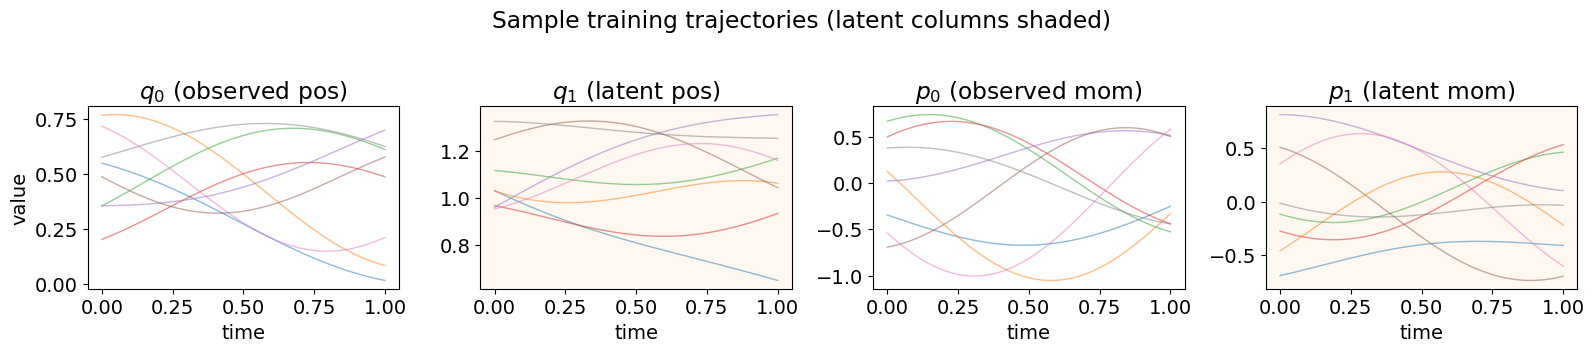

In [5]:
# ── Train / validation split ─────────────────────────────────────────────────
key, subkey = jax.random.split(key)
idx = jax.random.permutation(subkey, N_traj)
n_train = int(0.85 * N_traj)
train_data = x_ground_truth[idx[:n_train]]    # (N_train, T, 4)
val_data   = x_ground_truth[idx[n_train:]]    # (N_val,   T, 4)
print(f"Train: {train_data.shape[0]} trajectories  |  Val: {val_data.shape[0]} trajectories")

# ── Visualise a few training trajectories ────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
titles = ["$q_0$ (observed pos)", "$q_1$ (latent pos)",
          "$p_0$ (observed mom)", "$p_1$ (latent mom)"]
for j, (ax, title) in enumerate(zip(axes, titles)):
    for i in range(8):
        ax.plot(ts, train_data[i, :, j], alpha=0.5, lw=1)
    ax.set(xlabel="time", title=title)
    if j in (1, 3):
        ax.set_facecolor("#fff8f0")   # tint latent columns
axes[0].set_ylabel("value")
plt.suptitle("Sample training trajectories (latent columns shaded)", y=1.01)
plt.tight_layout()
plt.show()


## 3. Define the learned models

We compare four model variants, all trained on the same partial-observation loss.

### NHODE — potential energy 

Learns $U_\theta(q)$, $q \in \mathbb{R}^2$. Dynamics via:

$$\dot{q}_i = \frac{p_i}{m_i}, \qquad \dot{p}_i = -\frac{\partial U_\theta}{\partial q_i}$$

Masses are assumed **known**; energy conservation is **guaranteed by construction**.

### NHODE — total energy 

Learns $\mathcal{H}_\theta(x)$, $x \in \mathbb{R}^4$. Dynamics via:

$$\dot{q}_i = \frac{\partial \mathcal{H}_\theta}{\partial p_i}, \qquad \dot{p}_i = -\frac{\partial \mathcal{H}_\theta}{\partial q_i}$$

Masses are **not required**; still energy-conserving by construction.

### Physically-structured NODE 

Uses known masses for $\dot{q} = p/m$; learns $\dot{p} = f_\theta(x)$ with an MLP. Not energy-conserving.

### Vanilla NODE 

An MLP directly predicts $\dot{x} = f_\theta(x)$ — no physics structure.


In [6]:
# ── Model architectures ───────────────────────────────────────────────────────

class HamiltonianNN(eqx.Module):
    net: eqx.nn.MLP
    def __init__(self, key, in_size, hidden_dim=128, depth=3):
        self.net = eqx.nn.MLP(in_size=in_size, out_size=1,
                               width_size=hidden_dim, depth=depth,
                               activation=jax.nn.tanh, key=key)
    def __call__(self, x):
        return self.net(x)[0]   # scalar


class NeuralODE(eqx.Module):
    net: eqx.nn.MLP
    def __init__(self, key, in_size, out_size, hidden_dim=128, depth=3):
        self.net = eqx.nn.MLP(in_size=in_size, out_size=out_size,
                               width_size=hidden_dim, depth=depth,
                               activation=jax.nn.tanh, key=key)
    def __call__(self, y):
        return self.net(y)


# ── Vector fields (ODE right-hand sides) ──────────────────────────────────────

def vf_nhode_pot(t, x, args):
    """NHODEpot: dq/dt = p/m,  dp/dt = −∇_q U_θ(q).  x = [x0,x1,p0,p1]"""
    model, params = args
    masses = jnp.array([params.m0, params.m1])
    q, p = x[:2], x[2:]
    dqdt = p / masses
    dpdt = -jax.grad(model)(q)
    return jnp.concatenate([dqdt, dpdt])


def vf_nhode_tot(t, x, args):
    """NHODEtot: dx/dt from gradient of learned total H_θ(x).  x = [x0,x1,p0,p1]"""
    model, _ = args
    dHdx = jax.grad(model)(x)   # shape (4,)
    dqdt =  dHdx[2:]            # ∂H/∂p  →  q̇
    dpdt = -dHdx[:2]            # −∂H/∂q →  ṗ
    return jnp.concatenate([dqdt, dpdt])


def vf_node_phys(t, x, args):
    """NODE_phys: dq/dt = p/m (known masses),  dp/dt = MLP(x).  x = [x0,x1,p0,p1]"""
    model, params = args
    masses = jnp.array([params.m0, params.m1])
    q, p = x[:2], x[2:]
    dqdt = p / masses
    dpdt = model(x)             # output shape (2,)
    return jnp.concatenate([dqdt, dpdt])


def vf_node_vanilla(t, x, args):
    """NODE_vanilla: dx/dt = MLP(x).  x = [x0,x1,p0,p1]"""
    model, _ = args
    return model(x)             # output shape (4,)


# ── Instantiate models ────────────────────────────────────────────────────────
key, k1, k2, k3, k4 = jax.random.split(key, 5)
nhode_pot_model    = HamiltonianNN(k1, in_size=2, depth=3)  
nhode_tot_model    = HamiltonianNN(k2, in_size=4, depth=3)
node_phys_model    = NeuralODE(k3, in_size=4, out_size=2, depth=3)
node_vanilla_model = NeuralODE(k4, in_size=4, out_size=4, depth=3)

for name, model in [("NHODE_pot",     nhode_pot_model),
                    ("NHODE_tot",     nhode_tot_model),
                    ("NODE_phys",     node_phys_model),
                    ("NODE_vanilla",  node_vanilla_model)]:
    n = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array)))
    print(f"{name:15s}: {n:6d} parameters")


NHODE_pot      :  33537 parameters
NHODE_tot      :  33793 parameters
NODE_phys      :  33922 parameters
NODE_vanilla   :  34180 parameters


## 4. Train

All four models share the same training loop:

1. Integrate the learned ODE forward from the initial condition $y_0$.
2. Compute MSE loss on the observed states of $m_0$ only: $q_0$ and $p_0$ (indices 0 and 2). $m_1$ does not contribute to the loss.
3. Backpropagate through the ODE solver and update weights with Adam + exponential LR decay ($\times 0.95$ every 10 epochs).


In [7]:
# Observed: q0 (idx 0) + p0 (idx 2)  →  mass 0
# Latent:   q1 (idx 1) + p1 (idx 3)  →  mass 1
OBSERVED = jnp.array([0, 2])

EPOCHS = 100
BATCH_SIZE = 64
LEARNING_RATE = 1e-3

In [8]:
def make_integrator(vector_field, ts, params):
    """Return a vmapped batch integrator for a given vector field."""
    ts = jnp.asarray(ts)
    t0, t1 = float(ts[0]), float(ts[-1])
    term = dfx.ODETerm(vector_field)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts)
    controller = dfx.PIDController(rtol=1e-6, atol=1e-8)

    def solve_one(model, y0):
        sol = dfx.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=None,
                              y0=y0, args=(model, params),
                              saveat=saveat, stepsize_controller=controller)
        return sol.ys   # (T, 4)

    @eqx.filter_jit
    def run_batch(model, y0s):
        return jax.vmap(lambda y0: solve_one(model, y0))(y0s)

    return run_batch


def train(model, vector_field, ts, params, train_data, val_data,
          epochs=500, batch_size=64, lr=1e-3,
          lr_decay_rate=0.95, lr_decay_epochs=10,
          print_every=50, key=None):
    """Train with partial-observation MSE loss on observed states of m0."""
    if key is None:
        key = jax.random.PRNGKey(42)

    run_batch = make_integrator(vector_field, ts, params)

    # ── Exponential LR schedule ───────────────────────────────────────────────
    steps_per_epoch = train_data.shape[0] // batch_size
    schedule = optax.exponential_decay(
        init_value=lr,
        transition_steps=lr_decay_epochs * steps_per_epoch,
        decay_rate=lr_decay_rate,
        staircase=True,
    )
    optimizer = optax.adam(learning_rate=schedule)
    print(f"LR schedule: exponential decay ×{lr_decay_rate} every {lr_decay_epochs} epochs")

    model_params, model_static = eqx.partition(model, eqx.is_array)
    opt_state = optimizer.init(model_params)

    @eqx.filter_value_and_grad
    def loss_fn(model_params, batch):
        model = eqx.combine(model_params, model_static)
        pred  = run_batch(model, batch[:, 0, :])
        return jnp.mean((pred[..., OBSERVED] - batch[..., OBSERVED]) ** 2)

    @eqx.filter_jit
    def step(model_params, opt_state, batch):
        loss, grads = loss_fn(model_params, batch)
        updates, opt_state = optimizer.update(grads, opt_state, model_params)
        model_params = eqx.apply_updates(model_params, updates)
        return model_params, opt_state, loss

    train_losses, val_losses = [], []
    N = train_data.shape[0]
    global_step = 0

    for epoch in range(1, epochs + 1):
        key, subkey = jax.random.split(key)
        perm = jax.random.permutation(subkey, N)

        epoch_losses = []
        for i in range(0, N, batch_size):
            batch = train_data[perm[i:i + batch_size]]
            if batch.shape[0] < 2:
                continue
            model_params, opt_state, loss = step(model_params, opt_state, batch)
            epoch_losses.append(float(loss))
            global_step += 1

        train_loss = float(jnp.mean(jnp.array(epoch_losses)))
        val_pred   = run_batch(eqx.combine(model_params, model_static), val_data[:, 0, :])
        val_loss   = float(jnp.mean((val_pred[..., OBSERVED] - val_data[ :, ..., OBSERVED]) ** 2))
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if epoch % print_every == 0 or epoch == 1:
            current_lr = float(schedule(global_step))
            print(f"Epoch {epoch:4d}/{epochs}  train loss={train_loss:.6f}  val loss={val_loss:.6f}  lr={current_lr:.2e}")

    return eqx.combine(model_params, model_static), train_losses, val_losses


In [9]:
key, k1, k2, k3, k4 = jax.random.split(key, 5)

TRAIN_KWARGS = dict(
    ts=ts, params=params, train_data=train_data, val_data=val_data,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE,
    lr_decay_rate=0.95, lr_decay_epochs=10, print_every=25,
)

print("=" * 55)
print("Training NHODE_pot")
print("=" * 55)
nhode_pot_trained, nhode_pot_tl, nhode_pot_vl = train(
    nhode_pot_model, vf_nhode_pot, key=k1, **TRAIN_KWARGS)

print()
print("=" * 55)
print("Training NHODE_tot")
print("=" * 55)
nhode_tot_trained, nhode_tot_tl, nhode_tot_vl = train(
    nhode_tot_model, vf_nhode_tot, key=k2, **TRAIN_KWARGS)

print()
print("=" * 55)
print("Training NODE_phys")
print("=" * 55)
node_phys_trained, node_phys_tl, node_phys_vl = train(
    node_phys_model, vf_node_phys, key=k3, **TRAIN_KWARGS)

print()
print("=" * 55)
print("Training NODE_vanilla")
print("=" * 55)
node_vanilla_trained, node_van_tl, node_van_vl = train(
    node_vanilla_model, vf_node_vanilla, key=k4, **TRAIN_KWARGS)


Training NHODE_pot
LR schedule: exponential decay ×0.95 every 10 epochs
Epoch    1/100  train loss=0.130195  val loss=0.058206  lr=1.00e-03
Epoch   25/100  train loss=0.000005  val loss=0.000004  lr=9.03e-04
Epoch   50/100  train loss=0.000003  val loss=0.000003  lr=7.74e-04
Epoch   75/100  train loss=0.000003  val loss=0.000003  lr=6.98e-04
Epoch  100/100  train loss=0.000003  val loss=0.000001  lr=5.99e-04

Training NHODE_tot
LR schedule: exponential decay ×0.95 every 10 epochs
Epoch    1/100  train loss=0.140908  val loss=0.083235  lr=1.00e-03
Epoch   25/100  train loss=0.000123  val loss=0.000124  lr=9.03e-04
Epoch   50/100  train loss=0.000049  val loss=0.000045  lr=7.74e-04
Epoch   75/100  train loss=0.000046  val loss=0.000053  lr=6.98e-04
Epoch  100/100  train loss=0.000024  val loss=0.000036  lr=5.99e-04

Training NODE_phys
LR schedule: exponential decay ×0.95 every 10 epochs
Epoch    1/100  train loss=0.074600  val loss=0.033594  lr=1.00e-03
Epoch   25/100  train loss=0.00010

## 5. Results

### Training and validation loss curves


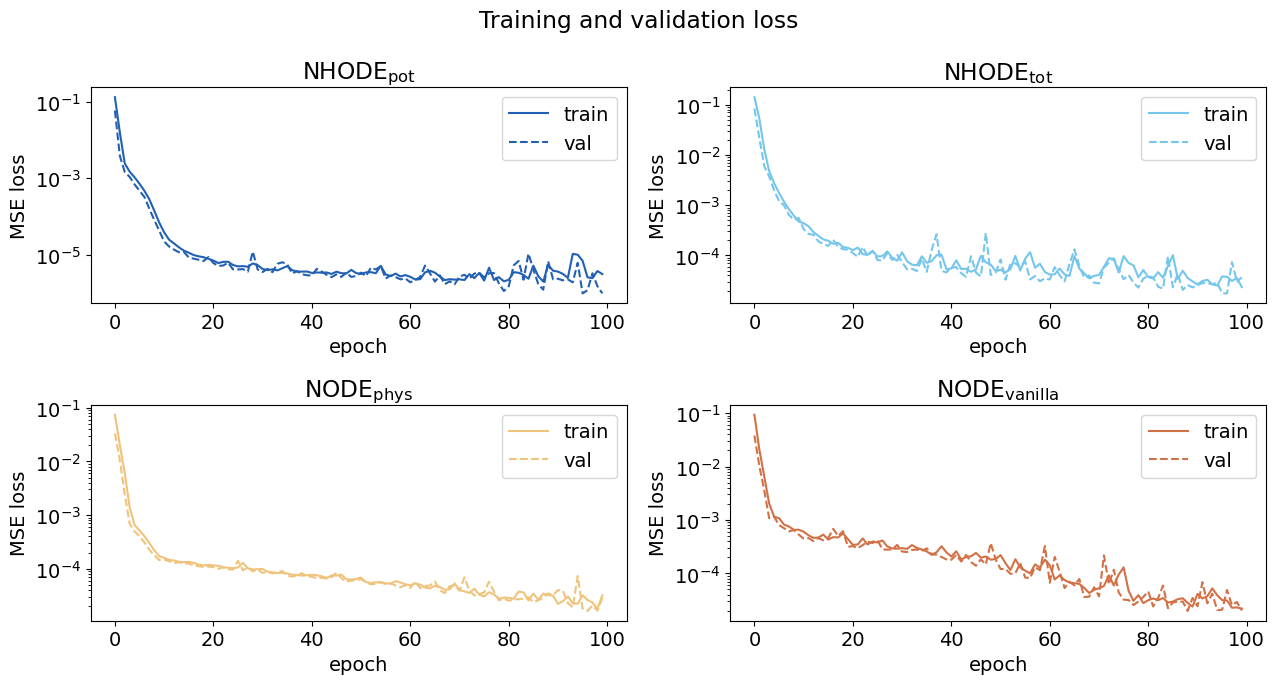

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

for ax, (mkey, tl, vl) in zip(axes.flat, [
    ("nhode_pot",    nhode_pot_tl, nhode_pot_vl),
    ("nhode_tot",    nhode_tot_tl, nhode_tot_vl),
    ("node_phys",    node_phys_tl, node_phys_vl),
    ("node_vanilla", node_van_tl,  node_van_vl),
]):
    color = COLORS[mkey]
    ax.semilogy(tl, color=color, label="train")
    ax.semilogy(vl, color=color, linestyle="--", label="val")
    ax.set(xlabel="epoch", ylabel="MSE loss", title=LABELS[mkey])
    ax.legend()

plt.suptitle("Training and validation loss")
plt.tight_layout()
plt.show()


### Trajectory comparison on held-out test cases

We integrate all four trained models from new initial conditions and compare to the ground truth. Shaded columns show the latent mass $m_1$, which was not observed during training.


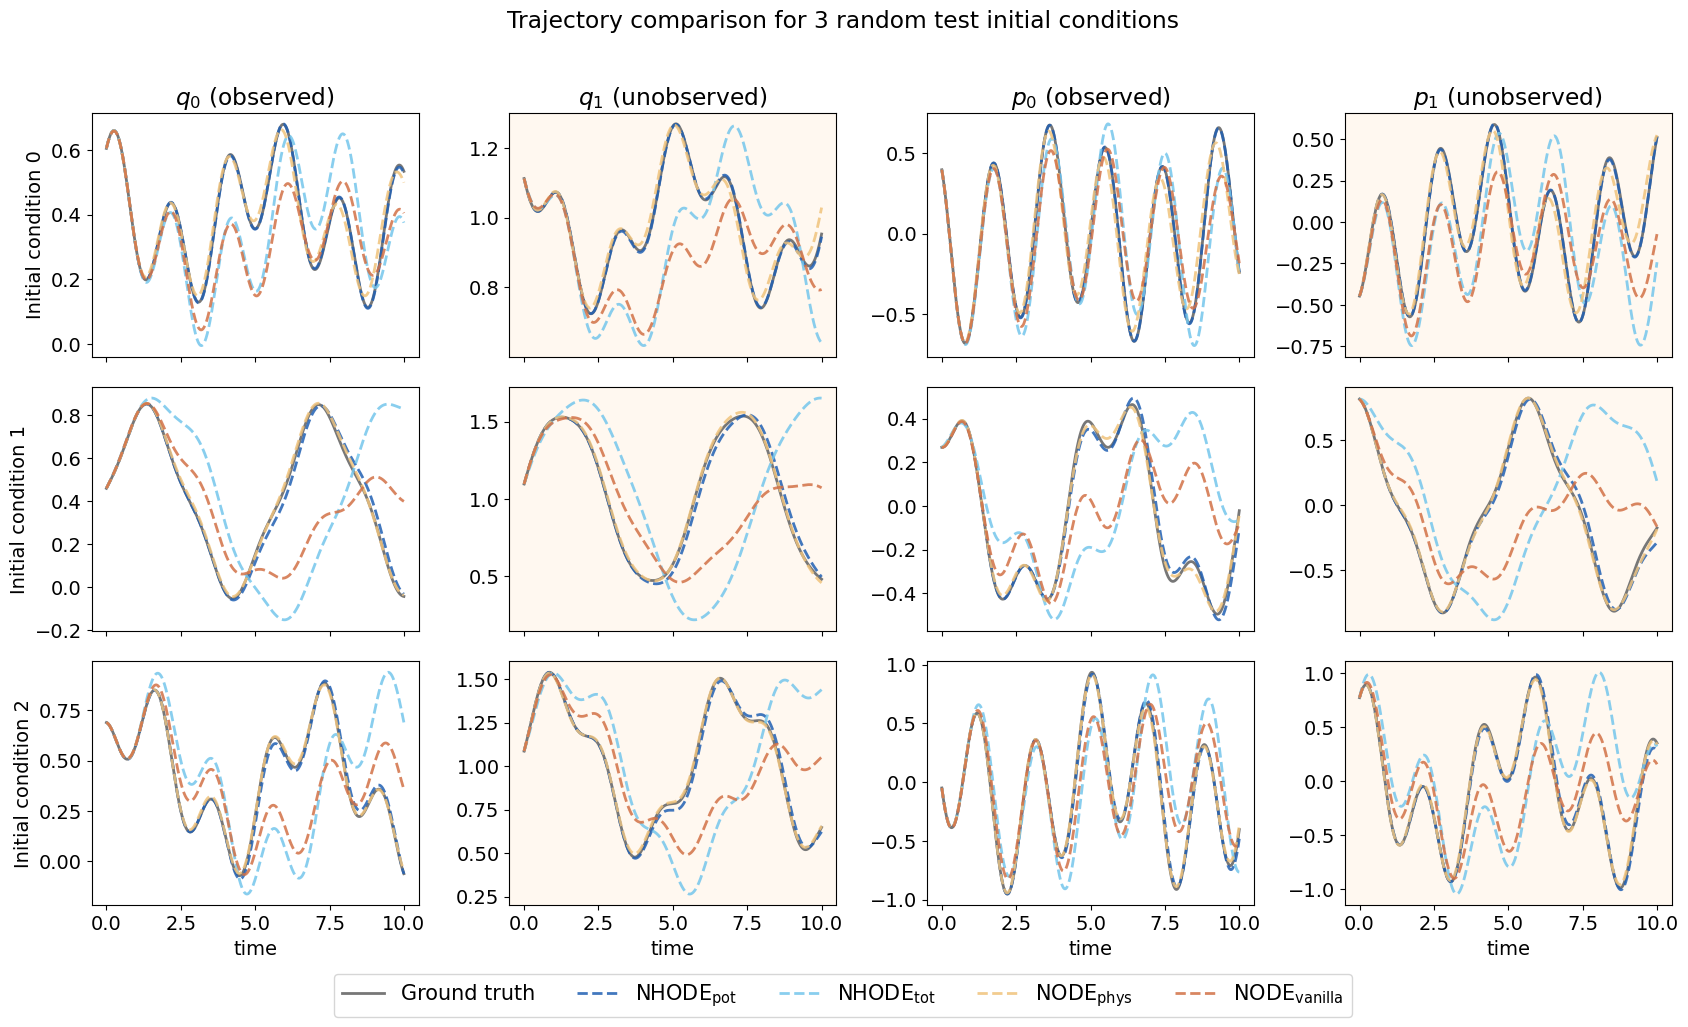

In [11]:
# ── Generate test trajectories ───────────────────────────────────────────────
key, subkey = jax.random.split(key)
N_test = 3
y0s_test  = sample_ic_batch(subkey, N_test, params)
ts_test = jnp.linspace(0.0, 10.0, 1001)   
true_test = integrate(true_vector_field, ts_test, params, y0s_test)   # (N_test, T, 4)

run_nhode_pot    = make_integrator(vf_nhode_pot,    ts_test, params)
run_nhode_tot    = make_integrator(vf_nhode_tot,    ts_test, params)
run_node_phys    = make_integrator(vf_node_phys,    ts_test, params)
run_node_vanilla = make_integrator(vf_node_vanilla, ts_test, params)

nhode_pot_pred    = run_nhode_pot(nhode_pot_trained,       true_test[:, 0, :])
nhode_tot_pred    = run_nhode_tot(nhode_tot_trained,       true_test[:, 0, :])
node_phys_pred    = run_node_phys(node_phys_trained,       true_test[:, 0, :])
node_van_pred     = run_node_vanilla(node_vanilla_trained, true_test[:, 0, :])

# ── Plot ──────────────────────────────────────────────────────────────────────
latent_dims = [(0, "$q_0$ (observed)",  False),
              (1, "$q_1$ (unobserved)", True),
              (2, "$p_0$ (observed)",   False),
              (3, "$p_1$ (unobserved)", True)]

model_preds = [
    ("nhode_pot",    nhode_pot_pred),
    ("nhode_tot",    nhode_tot_pred),
    ("node_phys",    node_phys_pred),
    ("node_vanilla", node_van_pred),
]

fig, axes = plt.subplots(N_test, 4, figsize=(17, 3.2 * N_test), sharex=True)

for i in range(N_test):
    for j, (dim, label, is_latent) in enumerate(latent_dims):
        ax = axes[i, j]
        ax.plot(ts_test, true_test[i, :, dim], color=COLORS["true"], lw=2.0, label=LABELS["true"])
        for mkey, pred in model_preds:
            ax.plot(ts_test, pred[i, :, dim], color=COLORS[mkey], lw=2.0,
                    linestyle="--", label=LABELS[mkey], alpha=0.85)
        if is_latent:
            ax.set_facecolor("#fff8f0")
        if i == 0:
            ax.set_title(label)
        ax.set_ylabel(f"Initial condition {i}" if j == 0 else "")
        if i == N_test - 1:
            ax.set_xlabel("time")

# ── Shared horizontal legend below all subplots ───────────────────────────────
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(handles),
           fontsize=15, bbox_to_anchor=(0.5, -0.05), frameon=True)

plt.suptitle(rf"Trajectory comparison for {N_test} random test initial conditions", y=1.01)
plt.tight_layout()
plt.show()


### Energy conservation

Compare the total energy implied by the learned models with the true total energy, by evaluating the true Hamiltonian on the predicted trajectories.

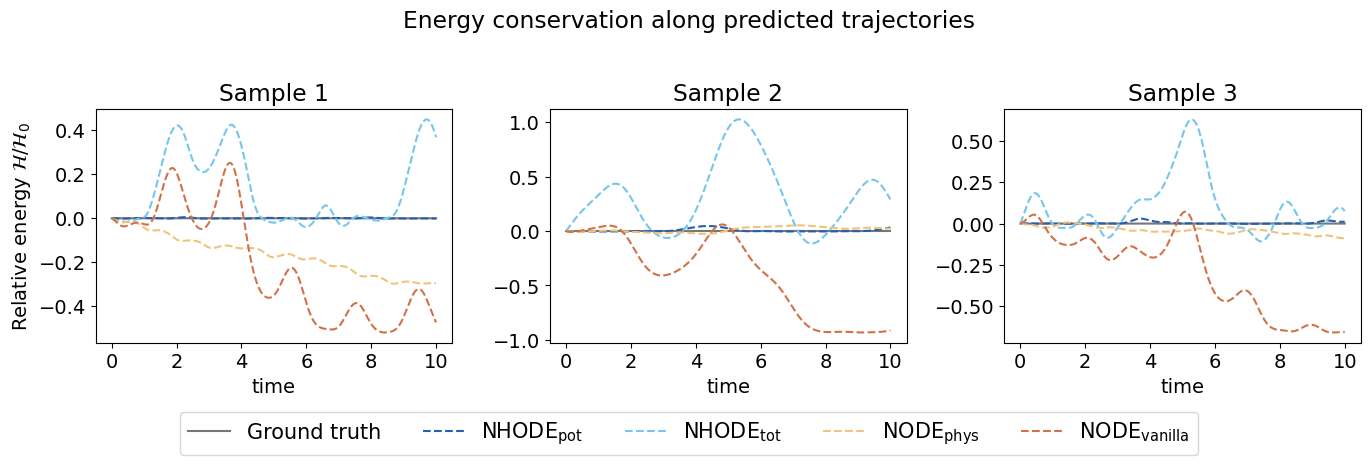

In [12]:
fig, axes = plt.subplots(1, N_test, figsize=(14, 4.0))

energy = lambda ys: jax.vmap(lambda y: true_hamiltonian(y, params))(ys)

for i, ax in enumerate(axes):
    E0 = energy(true_test[i])[0]   # reference energy at t=0
    for ys, mkey in [(true_test[i],       "true"),
                     (nhode_pot_pred[i],  "nhode_pot"),
                     (nhode_tot_pred[i],  "nhode_tot"),
                     (node_phys_pred[i],  "node_phys"),
                     (node_van_pred[i],   "node_vanilla")]:
        E = energy(ys)
        ax.plot(ts_test, (E - E0) / E0,
                color=COLORS[mkey], lw=1.5,
                linestyle="-" if mkey == "true" else "--",
                label=LABELS[mkey])
    ax.set(xlabel="time", title=f"Sample {i + 1}")
    if i == 0:
        ax.set_ylabel(r"Relative energy $\mathcal{H} / \mathcal{H}_0$")

# ── Shared horizontal legend below all subplots ───────────────────────────────
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(handles),
           fontsize=15, bbox_to_anchor=(0.5, -0.12), frameon=True)

plt.suptitle("Energy conservation along predicted trajectories", y=1.02)
plt.tight_layout()
plt.show()
